# Person 2 — Step 4: Title + Thumbnail Features vs. Engagement

Merges all extracted features and tests:
- Which title/thumbnail features most predict views and engagement rate?
- Do these predictors differ between institutional and independent channels?
- Does the Claude appeal score actually correlate with real engagement?

In [8]:
import sys
sys.path.append('../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

from shared.config import VIDEOS_CSV, CHANNELS_CSV, PERSON2_DIR

TABLES  = PERSON2_DIR / 'outputs' / 'tables'
FIGURES = PERSON2_DIR / 'outputs' / 'figures'

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {'independent': '#2ecc71', 'institutional': '#3498db'}

In [9]:
# Load all feature tables
videos   = pd.read_csv(VIDEOS_CSV)
channels = pd.read_csv(CHANNELS_CSV)[['channel_id', 'channel_title', 'group_label']]
base = videos.merge(channels, on='channel_id')
base['group_label'] = base['group_label'].str.lower()
base['like_rate']    = base['like_count']    / base['view_count']
base['comment_rate'] = base['comment_count'] / base['view_count']
base['log_views']    = np.log1p(base['view_count'])

title_feats = pd.read_csv(TABLES / 'title_stats_tests.csv')  # use raw features from step 1
cv_feats    = pd.read_csv(TABLES / 'opencv_features.csv')
clip_feats  = pd.read_csv(TABLES / 'clip_features.csv')

# Recompute title features inline (they were computed in notebook 1 but not saved as a per-video file)
# — if you saved them in step 1, load from CSV instead
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re

sia = SentimentIntensityAnalyzer()
POWER_WORDS = ['why','how','what','secret','truth','never','always','impossible',
               'actually','really','mind','blow','amazing','surprising','shocking',
               'explained','works','wrong','myth','debunk','discover','proof']

def title_features(t):
    t = str(t); tl = t.lower(); words = tl.split()
    v = sia.polarity_scores(t)
    return {'title_len_words': len(words), 'has_question': int('?' in t),
            'has_number': int(bool(re.search(r'\d', t))), 'has_colon': int(':' in t),
            'power_word_count': sum(1 for pw in POWER_WORDS if pw in words),
            'vader_compound': v['compound']}

tf = base['title'].apply(title_features).apply(pd.Series)
tf['video_id'] = base['video_id'].values

# Merge everything
merged = (
    base[['video_id','channel_title','group_label','view_count','log_views','like_rate','comment_rate']]
    .merge(tf, on='video_id')
    .merge(cv_feats, on='video_id', how='left')
    .merge(clip_feats, on='video_id', how='left')
)
print(f"Merged dataset: {merged.shape}")
merged.head()

Merged dataset: (9569, 26)


,video_id,channel_title,group_label,view_count,log_views,like_rate,comment_rate,title_len_words,has_question,has_number,...,colorfulness,edge_density,dominant_hue,clip_has_face,clip_is_animated,clip_has_text_overlay,clip_is_diagram,clip_is_colorful,clip_is_professional,clip_is_clickbait
0,--4MpKow8ro,Stanford,institutional,3119.0,8.045588,0.002565,0.000321,4.0,0.0,0.0,...,24.187401,0.036128,12.017794,0.032318,0.047816,0.744494,0.002581,0.627338,0.815921,0.301807
1,--ZfVZbmKbY,Stanford,institutional,4314.0,8.369853,0.008809,NaN,10.0,0.0,0.0,...,11.872387,0.038223,1.251975,0.313570,0.061886,0.801003,0.036256,0.128670,0.726237,0.134266
2,--aYHgPKGIs,ETH Zürich,institutional,99700.0,11.509931,0.010411,0.000171,3.0,1.0,0.0,...,34.739171,0.170411,8.266120,0.320189,0.003293,0.666272,0.329975,0.860883,0.977463,0.193920
3,--qKOhdgJAs,Stanford,institutional,178472.0,12.092193,0.013627,NaN,8.0,0.0,1.0,...,54.629972,0.043027,130.254313,0.051109,0.236653,0.776672,0.142242,0.982304,0.944813,0.082736
4,--sBEWfPfKA,Stanford,institutional,11831.0,9.378563,0.027132,NaN,7.0,0.0,0.0,...,30.727407,0.047286,23.456125,0.335543,0.020333,0.764227,0.009264,0.927001,0.649509,0.253811


## Spearman correlations with engagement

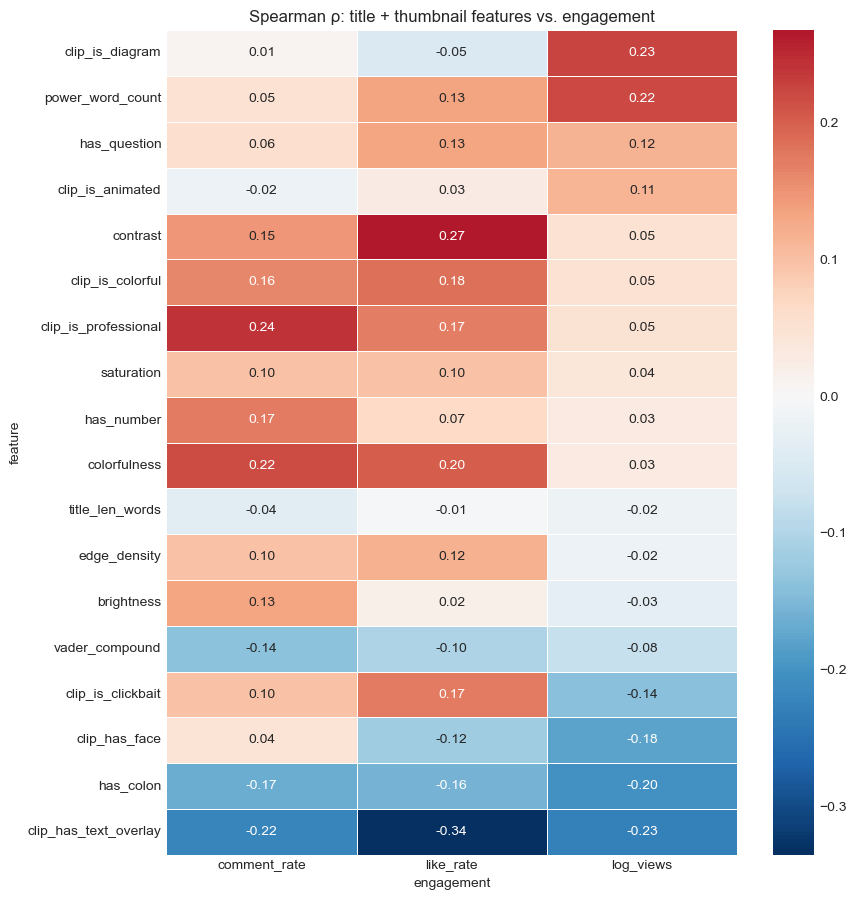

In [10]:
feature_cols = (
    ['title_len_words','has_question','has_number','has_colon','power_word_count','vader_compound'] +
    ['brightness','contrast','saturation','colorfulness','edge_density'] +
    [c for c in merged.columns if c.startswith('clip_')]
)
engagement_cols = ['log_views', 'like_rate', 'comment_rate']

corr_rows = []
for feat in feature_cols:
    for eng in engagement_cols:
        sub = merged[[feat, eng]].dropna()
        r, p = stats.spearmanr(sub[feat], sub[eng])
        corr_rows.append({'feature': feat, 'engagement': eng, 'rho': round(r, 3), 'p_value': round(p, 5)})

corr_df = pd.DataFrame(corr_rows)
pivot = corr_df.pivot(index='feature', columns='engagement', values='rho').sort_values('log_views', ascending=False)

fig, ax = plt.subplots(figsize=(9, len(pivot)*0.45 + 1))
sns.heatmap(pivot, annot=True, fmt='.2f', center=0, cmap='RdBu_r', linewidths=0.4, ax=ax)
ax.set_title('Spearman ρ: title + thumbnail features vs. engagement')
plt.tight_layout()
plt.savefig(FIGURES / 'full_correlation_heatmap.png', dpi=150)
plt.show()

## Random Forest feature importance (log views)

Training on 9567 rows (dropped 2 with NaN/inf)
CV R² = 0.513 ± 0.021


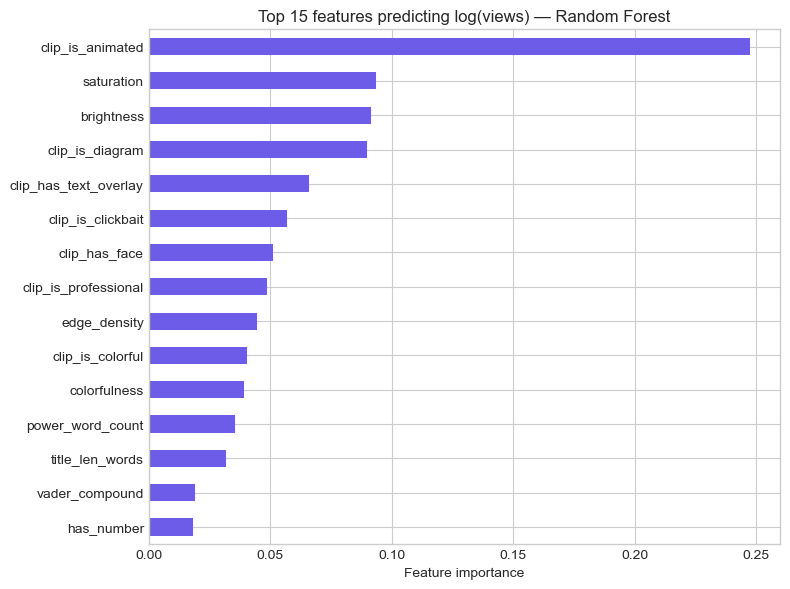

In [11]:
_df = (merged[feature_cols + ['log_views']]
       .replace([np.inf, -np.inf], np.nan)
       .dropna())
X = _df[feature_cols].values
y = _df['log_views'].values
print(f"Training on {len(_df)} rows (dropped {len(merged) - len(_df)} with NaN/inf)")

rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

# Cross-validated R²
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"CV R² = {scores.mean():.3f} ± {scores.std():.3f}")

rf.fit(X, y)
importances = pd.Series(rf.named_steps['rf'].feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='#6c5ce7')
ax.set_xlabel('Feature importance')
ax.set_title('Top 15 features predicting log(views) — Random Forest')
plt.tight_layout()
plt.savefig(FIGURES / 'rf_feature_importance.png', dpi=150)
plt.show()

## BLIP appeal score vs. real engagement (sample)

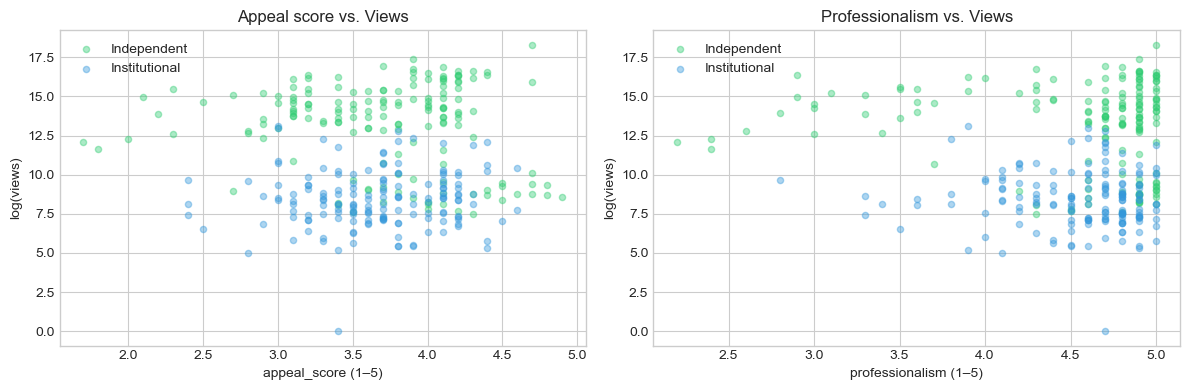

appeal_score               rho=+0.023  p=0.6852
professionalism            rho=+0.099  p=0.0778
complexity                 rho=-0.119  p=0.0336
curiosity_trigger          rho=-0.246  p=0.0000


In [7]:
vision_path = TABLES / 'vision_features.csv'
if vision_path.exists():
    vision_df = pd.read_csv(vision_path)
    v_merged = vision_df.merge(
        merged[['video_id','log_views','like_rate','group_label']], on='video_id', suffixes=('_vision', '')
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for grp, color in PALETTE.items():
        sub = v_merged[v_merged['group_label'].str.lower() == grp]
        axes[0].scatter(sub['appeal_score'], sub['log_views'], alpha=0.4, color=color, label=grp.title(), s=20)
        axes[1].scatter(sub['professionalism'], sub['log_views'], alpha=0.4, color=color, label=grp.title(), s=20)

    axes[0].set_xlabel('appeal_score (1–5)')
    axes[0].set_ylabel('log(views)')
    axes[0].set_title('Appeal score vs. Views')
    axes[0].legend()

    axes[1].set_xlabel('professionalism (1–5)')
    axes[1].set_ylabel('log(views)')
    axes[1].set_title('Professionalism vs. Views')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIGURES / 'blip_appeal_vs_engagement.png', dpi=150)
    plt.show()

    for feat in ['appeal_score', 'professionalism', 'complexity', 'curiosity_trigger']:
        r, p = stats.spearmanr(v_merged[feat], v_merged['log_views'])
        print(f"{feat:25s}  rho={r:+.3f}  p={p:.4f}")
else:
    print("Run notebook 03 first to generate BLIP vision features")